In [1]:
%pip install -q -U "gymnasium[mujoco]" "gymnasium[other]" "gymnasium[box2d]"
%pip install coppeliasim-zmqremoteapi-client tensorboard

import gymnasium as gym
import numpy as np
import time
import math  
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings ; warnings.filterwarnings('ignore')
import os
# os.environ['CUDA_DEVICE_ORDER']='PCI_BUS_ID'
# os.environ['OMP_NUM_THREADS'] = '1'
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from itertools import cycle, count

import os.path
import random
import time
import gymnasium as gym
import gc

In [24]:
import numpy as np
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


class CoppeliaZMQBridge:
    def __init__(self, host='localhost', port=23000):
        self.client = RemoteAPIClient(host=host, port=port)
        self.sim = self.client.require('sim')
        
        self.drone = None
        self.target = None
        self.pointA = None
        self.pointB = None
        self.drone_script =None
        self.reference_drawing= None

    def connect_scene(self):
        self.refresh_handles()
        print('drone handle:', self.drone)
        print('drone script handle:', self.drone_script)
        self.reference_drawing = None
        self.clear_all_reference_drawings()

    def refresh_handles(self):
        self.drone = self.sim.getObject('/Quadcopter')
        self.target = self.sim.getObject('/Target')
        self.pointA = self.sim.getObject('/PointA')
        self.pointB = self.sim.getObject('/PointB')
        self.drone_script = self.sim.getScript(
            self.sim.scripttype_simulation,
            self.drone,
            ''
        )

    def start(self):
        self.sim.setStepping(True)
        self.sim.startSimulation()

    def stop(self):
        self.sim.stopSimulation()

    def step(self):
        self.sim.step()

    def clear_all_reference_drawings(self):
        try:
            self.sim.removeDrawingObject(self.sim.handle_all)
        except Exception as e:
            print(f"Errore nella pulizia dei drawing objects: {e}")

        self.reference_drawing = None

    def get_position(self, handle):
        return np.array(self.sim.getObjectPosition(handle, -1), dtype=np.float32)
    
    def reset_dynamics(self, handle):
        self.sim.resetDynamicObject(handle)

    def get_orientation(self, handle):
        return np.array(self.sim.getObjectOrientation(handle, -1), dtype=np.float32)
    
    def get_matrix(self, handle):
        m = self.sim.getObjectMatrix(handle, -1)  # 12 valori
        m = np.array(m, dtype=np.float32).reshape(3, 4)
        return m[:, :3] #return solo la matrice di rotazione 3x3

    def get_velocity(self, handle):
        lin, ang = self.sim.getObjectVelocity(handle)
        return np.array(lin, dtype=np.float32), np.array(ang, dtype=np.float32)

    def set_pose(self, handle, pos, euler):
        self.sim.setObjectPosition(handle, -1, pos.tolist())
        self.sim.setObjectOrientation(handle, -1, euler.tolist())

    def set_target_position(self, pos):
        self.sim.setObjectPosition(self.target, -1, pos.tolist())
   
    def set_A_B_position(self, pos, name):
        if name == "A":
            self.sim.setObjectPosition(self.pointA, -1, pos.tolist())
        else:
            self.sim.setObjectPosition(self.pointB, -1, pos.tolist())

    def draw_reference_point(self, point, color=[1.0, 0.0, 0.0]):
        """
        Disegna il punto di riferimento su cui il drone deve fare hovering.

        Usa planner(0) per ottenere p_d, cioè la posizione desiderata.
        """
        if self.reference_drawing is None:
                self.reference_drawing = self.sim.addDrawingObject(
                    self.sim.drawing_points,
                    10,
                    0.0,
                    -1,
                    1,
                    color
                )

        # pulisce il contenuto precedente del drawing object
        self.sim.addDrawingObjectItem(self.reference_drawing, None)

        # aggiunge il nuovo punto
        self.sim.addDrawingObjectItem(self.reference_drawing, point.tolist())

    def clear_reference_point(self):
        if self.reference_drawing is not None:
            self.sim.removeDrawingObject(self.reference_drawing)
            self.reference_drawing = None


    def apply_motor_thrusts(self, thrusts):
        thrusts = np.asarray(thrusts, dtype=np.float32).tolist()
        self.sim.callScriptFunction(
            'setMotorThrusts',
            self.drone_script,
            {'thrusts': thrusts}
        )


In [14]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np


class DroneEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, host='localhost', port=23000, task="hovering"):
        super().__init__()

        self.bridge = CoppeliaZMQBridge(host=host, port=port)
        self.bridge.connect_scene()
        self.bridge.start()

        #Cambiamenti point-to-point
        self.task = task         # "hovering" or "point-to-point"
        if self.task=="point-to-point":
            self.point_A = np.array([0., 0., 1.5], dtype=np.float32)
            self.point_B = np.array([1., 0., 1.5], dtype=np.float32)
            self.path_speed = 0.2             # m/s
            self.path_progress = 0.0 
            self.path_dir = self.point_B - self.point_A
            self.path_length = np.linalg.norm(self.path_dir)
            self.dt = 0.05 #tempo di aggiornamento bersaglio
        
        self.stabilized = False
        self.target_pos = np.array([0., 0., 1.5], dtype=np.float32)
        self.prev_action = np.zeros(4, dtype=np.float32)
        self.max_steps = 400
        self.step_count = 0

        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(4,), dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(25,), dtype=np.float32
        )

    def _init_position(self):
        return np.array([
            np.random.uniform(-1.0, 1.0),
            np.random.uniform(-1.0, 1.0),
            np.random.uniform(1.3, 1.7)
        ], dtype=np.float32)

    def _init_orientation(self):
        deg = np.pi / 180.0
        return np.array([
            np.random.uniform(-5, 5) * deg,
            np.random.uniform(-5, 5) * deg,
            np.random.uniform(-10, 10) * deg
        ], dtype=np.float32)

    def _action_to_thrust(self, action):
        hover = 1.35      # esempio iniziale, da tarare
        delta = 0.4      # correzione massima
        thrusts = hover + delta * action
        return np.clip(thrusts, 0.0, 8.0)
    
    def _update_trajectory(self):
        if self.path_length < 1e-6: #se la distanza A-B è abbastanza piccola, siamo già in B
            self.target_pos = self.point_B.copy()
            return

        ds = (self.path_speed * self.dt) / self.path_length #valore tra [0,1], spostamento ad ogni step
        self.path_progress = min(self.path_progress + ds, 1.0) #clamping valore massimo ad 1 per non superare B
        #se ds=0 siamo in A, se ds=1 siamo in B
        self.target_pos = self.point_A + self.path_progress * (self.point_B - self.point_A)

    def _get_obs(self):
        drone_pos = self.bridge.get_position(self.bridge.drone)
        pos_err = self.target_pos - drone_pos

        rotation = self.bridge.get_matrix(self.bridge.drone).reshape(-1)

        rpy = self.bridge.get_orientation(self.bridge.drone)

        lin_vel, ang_vel = self.bridge.get_velocity(self.bridge.drone)

        #state vector dimention 25
        obs = np.concatenate([
            pos_err, #dim 3
            rotation, #dim 9
            rpy, #dim 3
            lin_vel, #dim 3
            ang_vel, #dim 3
            self.prev_action #dim 4 (motors)
        ]).astype(np.float32)

        return obs

    def _compute_reward(self, obs):
        pos_err = obs[0:3]
        rpy = obs[12:15]
        lin_vel = obs[15:18]
        ang_vel = obs[18:21]

        roll = rpy[0]
        pitch = rpy[1]

        reward = 1.5 #stay alive coefficient
        reward -= 1.5 * np.linalg.norm(pos_err) #euclidean distance
        #penalità con roll e pitch piccoli
        reward -= 0.30 * abs(roll)
        reward -= 0.30 * abs(pitch)
        reward -= 0.05 * abs(ang_vel[0])
        reward -= 0.05 * abs(ang_vel[1])
        reward -= 0.10 * abs(ang_vel[2])
        reward -= 0.02 * np.linalg.norm(lin_vel)
        return float(reward)

    def _terminated(self):
        pos = self.bridge.get_position(self.bridge.drone)
        rpy = self.bridge.get_orientation(self.bridge.drone)

        #se il drone sta cascando
        if pos[2] < 0.1:
            return True

        #se sei distante dal target di più di 5m
        if np.linalg.norm(self.target_pos - pos) > 5.0: 
            return True

        #se roll o pitch fanno una rotazione di più 90 gradi
        if abs(rpy[0]) > np.deg2rad(90) or abs(rpy[1]) > np.deg2rad(90):
            return True

        return False

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.target_pos = np.array([0., 0., 1.5], dtype=np.float32)
        self.bridge.set_target_position(self.target_pos)

        #Resetta valori point to point
        if self.task == "point-to-point" :
            #ha senso forse spawnarlo direttamente nel target invece che in un intorno come facciamo ora?
            init_pos = np.array([
                np.random.uniform(-0.2, 0.2),
                np.random.uniform(-0.2, 0.2),
                np.random.uniform(1.3, 1.7)
            ], dtype=np.float32)
            self.bridge.set_A_B_position(self.point_A, "A")
            self.bridge.set_A_B_position(self.point_B, "B")
            self.path_progress = 0.0 
            self.stabilized = False
            self.bridge.clear_reference_point()

        else: 
            init_pos = self._init_position()
            self.bridge.clear_reference_point()

        init_rpy = self._init_orientation()
        self.bridge.set_pose(self.bridge.drone, init_pos, init_rpy)
        self.bridge.reset_dynamics(self.bridge.drone)

        self.prev_action[:] = 0.0
        self.step_count = 0
        self.bridge.apply_motor_thrusts([1.35, 1.35, 1.35, 1.35]) #thrust neutro quasi hover

        obs = self._get_obs()
        info = {}
        return obs, info

    def step(self, action):
        action = np.clip(action, -1.0, 1.0).astype(np.float32)
                    
        # point to point traiettoria
        drone_pos_now = self.bridge.get_position(self.bridge.drone)
        lin_vel_now, _ = self.bridge.get_velocity(self.bridge.drone)
        rpy_now = self.bridge.get_orientation(self.bridge.drone)
        roll = abs(rpy_now[0])
        pitch = abs(rpy_now[1])

        if self.task == "point-to-point":
            dist_to_A = np.linalg.norm(self.point_A - drone_pos_now)
            speed = np.linalg.norm(lin_vel_now)
            self.bridge.draw_reference_point(self.point_A, color=[0.0, 1.0, 0.0])
            self.bridge.draw_reference_point(self.point_B, color=[1.0, 0.0, 0.0])

            if not self.stabilized:
                self.target_pos = self.point_A.copy()

                # quando il drone è vicino al punto e sufficientemente fermo e non oscilla, parte la traiettoria
                if dist_to_A < 0.02 and speed < 0.04 and roll < np.deg2rad(1) and pitch < np.deg2rad(1):
                    self.stabilized = True
            else:
                self._update_trajectory()
        else:
            self.bridge.draw_reference_point(self.target_pos)

            
        self.bridge.set_target_position(self.target_pos)

        thrusts = self._action_to_thrust(action) #calcolo il thrust dei motori tramite l'azione SAC
        self.bridge.apply_motor_thrusts(thrusts) #applico il thrust ai motori richiamando lo script LUA
        self.bridge.step() #inizia la simulazione

        obs = self._get_obs()
        reward = self._compute_reward(obs)
        terminated = self._terminated()
        truncated = (self.step_count + 1 >= self.max_steps)

        self.prev_action = action.copy()
        self.step_count += 1

        drone_pos = self.bridge.get_position(self.bridge.drone)
        pos_err = obs[0:3]
        lin_vel = obs[15:18]
        ang_vel = obs[18:21]

        info = {
            "drone_pos": drone_pos.copy(),
            "target_pos": self.target_pos.copy(),
            "pos_err": pos_err.copy(),
            "lin_vel": lin_vel.copy(),
            "ang_vel": ang_vel.copy(),
            "thrusts": thrusts.copy(),
            "step_count": self.step_count,
        }

        if self.task == "point-to-point":
            info.update({
                "stabilized": self.stabilized,
                "pointA": self.point_A.copy(),
                "pointB": self.point_B.copy(),
            })
        return obs, reward, terminated, truncated, info

    def close(self):
        self.bridge.stop()

In [15]:
#Test per vedere se gira l'env in Coppelia
env = DroneEnv(host='localhost', port=23000)
obs, info = env.reset()

print(obs.shape)

for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print("reward:", reward, "terminated:", terminated, "truncated:", truncated)
    print("step info:", info)

env.close()

drone handle: 16
drone script handle: 17
(25,)
reward: -8.87508773803711 terminated: False truncated: False
step info: {'drone_pos': array([-0.05169179, -0.00475678,  1.3465016 ], dtype=float32), 'target_pos': array([0. , 0. , 1.5], dtype=float32), 'pos_err': array([0.05169179, 0.00475678, 0.15349841], dtype=float32), 'lin_vel': array([ 32.48686 , -18.557571,  26.651484], dtype=float32), 'ang_vel': array([61.810337  ,  0.21707681, 61.73584   ], dtype=float32), 'thrusts': array([1.1812459, 0.9551332, 1.4831884, 1.3093421], dtype=float32), 'step_count': 1}
reward: 1.2343579530715942 terminated: False truncated: False
step info: {'drone_pos': array([-0.05189642, -0.00544834,  1.2977264 ], dtype=float32), 'target_pos': array([0. , 0. , 1.5], dtype=float32), 'pos_err': array([0.05189642, 0.00544834, 0.2022736 ], dtype=float32), 'lin_vel': array([-0.00409252, -0.01383109, -0.97550434], dtype=float32), 'ang_vel': array([-0.2599739 ,  0.1979131 ,  0.01887314], dtype=float32), 'thrusts': array(

In [ ]:
import numpy as np

#Test per tarare il parametro di hover che utilizzo in _action_to_thrust() in DroneEnv
env = DroneEnv(host='localhost', port=23000)

obs, info = env.reset()

print("Reset fatto")
print("obs shape:", obs.shape)

for t in range(30):
    action = np.zeros(4, dtype=np.float32)   # nessuna correzione SAC
    obs, reward, terminated, truncated, info = env.step(action)

    z = info["drone_pos"][2]
    pos_err = info["pos_err"]
    thrusts = info["thrusts"]

    print(
        f"step={t:02d} | z={z:.3f} | "
        f"pos_err=({pos_err[0]:.3f}, {pos_err[1]:.3f}, {pos_err[2]:.3f}) | "
        f"thrusts={thrusts} | reward={reward:.3f}"
    )

    if terminated or truncated:
        print("Episodio finito")
        break

env.close()

drone handle: 16
drone script handle: 17
Reset fatto
obs shape: (25,)
step=00 | z=1.321 | pos_err=(-0.005, 0.186, 0.179) | thrusts=[1.35 1.35 1.35 1.35] | reward=0.165
step=01 | z=1.297 | pos_err=(-0.006, 0.186, 0.203) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.176
step=02 | z=1.275 | pos_err=(-0.009, 0.188, 0.225) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.159
step=03 | z=1.254 | pos_err=(-0.014, 0.192, 0.246) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.140
step=04 | z=1.234 | pos_err=(-0.021, 0.196, 0.266) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.121
step=05 | z=1.215 | pos_err=(-0.030, 0.202, 0.285) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.101
step=06 | z=1.198 | pos_err=(-0.041, 0.209, 0.302) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.081
step=07 | z=1.182 | pos_err=(-0.054, 0.217, 0.318) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.061
step=08 | z=1.168 | pos_err=(-0.069, 0.226, 0.332) | thrusts=[1.35 1.35 1.35 1.35] | reward=1.041
step=09 | z=1.155 | pos_err=(-0.086, 0.237, 0.34

# SAC

In [5]:
LEAVE_PRINT_EVERY_N_SECS = 120
ERASE_LINE = '\x1b[2K'
RESULTS_DIR = os.path.join('..', 'results')

In [6]:
class ReplayBuffer():
    def __init__(self, 
                 max_size=10000, 
                 batch_size=64):
        self.ss_mem = np.empty(shape=(max_size), dtype=np.ndarray)
        self.as_mem = np.empty(shape=(max_size), dtype=np.ndarray)
        self.rs_mem = np.empty(shape=(max_size), dtype=np.ndarray)
        self.ps_mem = np.empty(shape=(max_size), dtype=np.ndarray)
        self.ds_mem = np.empty(shape=(max_size), dtype=np.ndarray)

        self.max_size = max_size
        self.batch_size = batch_size
        self._idx = 0
        self.size = 0
    
    def store(self, sample):
        s, a, r, p, d = sample
        self.ss_mem[self._idx] = s
        self.as_mem[self._idx] = a
        self.rs_mem[self._idx] = r
        self.ps_mem[self._idx] = p
        self.ds_mem[self._idx] = d
        
        self._idx += 1
        self._idx = self._idx % self.max_size

        self.size += 1
        self.size = min(self.size, self.max_size)

    def sample(self, batch_size=None):
        if batch_size == None:
            batch_size = self.batch_size

        idxs = np.random.choice(
            self.size, batch_size, replace=False)
        experiences = np.vstack(self.ss_mem[idxs]), \
                      np.vstack(self.as_mem[idxs]), \
                      np.vstack(self.rs_mem[idxs]), \
                      np.vstack(self.ps_mem[idxs]), \
                      np.vstack(self.ds_mem[idxs])
        return experiences

    def __len__(self):
        return self.size

In [7]:

class QNetwork(nn.Module):
    def __init__(self, 
                 input_dim, 
                 action_dim, 
                 hidden_dims=(32,32), 
                 activation_fc=F.relu,
                 device=torch.device("cpu")):
        super(QNetwork, self).__init__()
        self.activation_fc = activation_fc
        self.device = device

        # Costruzione dinamica dei layer
        self.input_layer = nn.Linear(input_dim + action_dim, hidden_dims[0])
        self.hidden_layers = nn.ModuleList()
        for i in range(len(hidden_dims)-1):
            hidden_layer = nn.Linear(hidden_dims[i], hidden_dims[i+1])
            self.hidden_layers.append(hidden_layer)
        self.output_layer = nn.Linear(hidden_dims[-1], 1)
        
        self.to(self.device)

    def forward(self, state, action):
        x = torch.cat((state, action), dim=1)
        x = self.activation_fc(self.input_layer(x))
        for hidden_layer in self.hidden_layers:
            x = self.activation_fc(hidden_layer(x))
        x = self.output_layer(x)
        return x

    def load(self, experiences):
        # Estraiamo i dati dal buffer
        # L'ordine deve corrispondere a quello del ReplayBuffer.sample():
        # states, actions, rewards, next_states, dones
        states, actions, rewards, new_states, is_terminals = experiences
        
        # --- FIX PER MAC MPS (Numpy not available) ---
        # Invece di torch.from_numpy(...).float().to(...)
        # Usiamo torch.tensor(..., dtype=torch.float32, device=...)
        # Questo costringe Python a convertire i dati PRIMA di passarli a Metal/MPS
        
        states = torch.tensor(states, device=self.device, dtype=torch.float32)
        actions = torch.tensor(actions, device=self.device, dtype=torch.float32)
        rewards = torch.tensor(rewards, device=self.device, dtype=torch.float32)
        new_states = torch.tensor(new_states, device=self.device, dtype=torch.float32)
        is_terminals = torch.tensor(is_terminals, device=self.device, dtype=torch.float32)

        return states, actions, rewards, new_states, is_terminals

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import numpy as np

class Policy(nn.Module):
    def __init__(self, 
                 input_dim, 
                 action_bounds,
                 log_std_min=-20, 
                 log_std_max=2,
                 hidden_dims=(32,32),
                 entropy_lr=0.001,
                 device=torch.device("cpu")):
        
        super(Policy, self).__init__()
        self.activation_fc = F.relu
        self.env_min, self.env_max = action_bounds
        
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max
        
        self.input_layer = nn.Linear(input_dim, hidden_dims[0])
        
        self.hidden_layers = nn.ModuleList()
        for i in range(len(hidden_dims)-1):
            hidden_layer = nn.Linear(hidden_dims[i], hidden_dims[i+1])
            self.hidden_layers.append(hidden_layer)

        self.output_layer_mean = nn.Linear(hidden_dims[-1], len(self.env_max))
        self.output_layer_log_std = nn.Linear(hidden_dims[-1], len(self.env_max))

        self.device = device
        self.to(self.device)

        # Bounds su device corretto
        self.env_min = torch.tensor(self.env_min, device=self.device, dtype=torch.float32)
        self.env_max = torch.tensor(self.env_max, device=self.device, dtype=torch.float32)
        
        self.nn_min = torch.tanh(torch.tensor([float('-inf')], device=self.device, dtype=torch.float32))
        self.nn_max = torch.tanh(torch.tensor([float('inf')], device=self.device, dtype=torch.float32))
        
        self.rescale_fn = lambda x: (x - self.nn_min) * (self.env_max - self.env_min) / \
                                    (self.nn_max - self.nn_min) + self.env_min

        target_entropy_val = -float(np.prod(self.env_max.shape))
        self.target_entropy = torch.tensor(target_entropy_val, device=self.device, dtype=torch.float32)
        self.logalpha = torch.zeros(1, requires_grad=True, device=self.device, dtype=torch.float32)
        self.alpha_optimizer = optim.Adam([self.logalpha], lr=entropy_lr)

    def _format(self, state):
        x = state
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, device=self.device, dtype=torch.float32)
            x = x.unsqueeze(0)
        return x

    def forward(self, state):
        x = self._format(state)
        x = self.activation_fc(self.input_layer(x))
        for hidden_layer in self.hidden_layers:
            x = self.activation_fc(hidden_layer(x))
        x_mean = self.output_layer_mean(x)
        x_log_std = self.output_layer_log_std(x)
        x_log_std = torch.clamp(x_log_std, self.log_std_min, self.log_std_max)
        return x_mean, x_log_std

    def full_pass(self, state, epsilon=1e-6):
        mean, log_std = self.forward(state)
        pi_s = Normal(mean, log_std.exp())
        pre_tanh_action = pi_s.rsample()
        tanh_action = torch.tanh(pre_tanh_action)
        action = self.rescale_fn(tanh_action)

        log_prob = pi_s.log_prob(pre_tanh_action) - torch.log(
            (1 - tanh_action.pow(2)).clamp(0, 1) + epsilon)
        log_prob = log_prob.sum(dim=1, keepdim=True)

        return action, log_prob, self.rescale_fn(torch.tanh(mean))

    def _update_exploration_ratio(self, greedy_action, action_taken):
        # FIX CRUCIALE: dtype=torch.float32
        t_greedy = torch.tensor(greedy_action, device=self.device, dtype=torch.float32)
        t_taken = torch.tensor(action_taken, device=self.device, dtype=torch.float32)
        
        diff = torch.abs(t_greedy - t_taken)
        rnge = self.env_max - self.env_min
        self.exploration_ratio = torch.mean(diff / rnge).item()

    def _get_actions(self, state):
        mean, log_std = self.forward(state)

        # 1. Action campionata
        action_tensor = self.rescale_fn(torch.tanh(Normal(mean, log_std.exp()).sample()))
        
        # 2. Greedy Action
        greedy_tensor = self.rescale_fn(torch.tanh(mean))
        
        # 3. Random Action (generata su Torch in float32)
        rand_tensor = torch.rand_like(self.env_min, dtype=torch.float32)
        random_tensor = self.env_min + (self.env_max - self.env_min) * rand_tensor
        
        # Convertiamo tutto in NumPy specificando float32
        action = np.array(action_tensor.detach().cpu().tolist(), dtype=np.float32)
        greedy_action = np.array(greedy_tensor.detach().cpu().tolist(), dtype=np.float32)
        random_action = np.array(random_tensor.detach().cpu().tolist(), dtype=np.float32)

        # Shape fix
        target_shape = tuple(self.env_max.shape)
        action = action.reshape(target_shape)
        greedy_action = greedy_action.reshape(target_shape)
        random_action = random_action.reshape(target_shape)

        return action, greedy_action, random_action

    def select_random_action(self, state):
        action, greedy_action, random_action = self._get_actions(state)
        self._update_exploration_ratio(greedy_action, random_action)
        return random_action

    def select_greedy_action(self, state):
        action, greedy_action, random_action = self._get_actions(state)
        self._update_exploration_ratio(greedy_action, greedy_action)
        return greedy_action

    def select_action(self, state):
        action, greedy_action, random_action = self._get_actions(state)
        self._update_exploration_ratio(greedy_action, action)
        return action

In [9]:
class SAC(nn.Module):
    def __init__(self, 
                 env_instance,
                 buffer_capacity,
                 batch_size,
                 policy_hidden_dims,
                 policy_optimizer_lr,
                 policy_max_grad_norm,
                 value_hidden_dims,
                 value_optimizer_lr,
                 value_max_grad_norm, 
                 n_warmup_batches,
                 update_target_every_steps,
                 tau,
                 checkpoint_freq=5,
                device=torch.device("cuda")):

        
        super().__init__()

        self.env_name = "ZMQ_Drone_Custom"
        env = env_instance
        nS, nA = env.observation_space.shape[0], env.action_space.shape[0]
        action_bounds = env.action_space.low, env.action_space.high
        
        print(f"Environment info:\n"
              f"  Observation space: {nS}\n"
              f"  Number of actions: {nA}\n"
              f"  Action bounds:\n"
              f"    Low : {action_bounds[0]}\n"
              f"    High: {action_bounds[1]}")
        
        self.replay_buffer = ReplayBuffer(max_size=buffer_capacity, batch_size=batch_size)
        
        self.device = device

        self.policy_hidden_dims = policy_hidden_dims
        self.policy_model = Policy(nS, action_bounds, hidden_dims=self.policy_hidden_dims, device=self.device)
        self.policy_optimizer_lr = policy_optimizer_lr
        self.policy_optimizer = optim.Adam(self.policy_model.parameters(),
                                           lr=self.policy_optimizer_lr)

        self.value_hidden_dims = value_hidden_dims
        self.target_value_model_a = QNetwork(nS, nA, hidden_dims=self.value_hidden_dims, device=self.device)
        self.online_value_model_a = QNetwork(nS, nA, hidden_dims=self.value_hidden_dims, device=self.device)
        
        self.target_value_model_b = QNetwork(nS, nA, hidden_dims=self.value_hidden_dims, device=self.device)
        self.online_value_model_b = QNetwork(nS, nA, hidden_dims=self.value_hidden_dims, device=self.device)
        
        self.value_optimizer_lr = value_optimizer_lr
        self.value_optimizer_a = optim.Adam(self.online_value_model_a.parameters(),
                                       self.value_optimizer_lr)
        self.value_optimizer_b = optim.Adam(self.online_value_model_b.parameters(),
                                       self.value_optimizer_lr)

        self.policy_max_grad_norm = policy_max_grad_norm
        
        self.value_max_grad_norm = value_max_grad_norm
    

        self.n_warmup_batches = n_warmup_batches
        self.update_target_every_steps = update_target_every_steps

        self.tau = tau

        self.checkpoint_freq = checkpoint_freq

    def optimize_model(self, experiences):
        states, actions, rewards, next_states, is_terminals = experiences
        batch_size = len(is_terminals)

        # ======================================================
        # alpha update
        # ======================================================
        _, logpi_s, _ = self.policy_model.full_pass(states)

        target_alpha = (logpi_s + self.policy_model.target_entropy).detach()
        alpha_loss = -(self.policy_model.logalpha * target_alpha).mean()

        self.policy_model.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.policy_model.alpha_optimizer.step()

        alpha = self.policy_model.logalpha.exp().detach()

        # ======================================================
        # Q loss (policy with no grad)
        # ======================================================
        with torch.no_grad():
            ap, logpi_sp, _ = self.policy_model.full_pass(next_states)

        q_spap_a = self.target_value_model_a(next_states, ap)
        q_spap_b = self.target_value_model_b(next_states, ap)
        q_spap = torch.min(q_spap_a, q_spap_b) - alpha * logpi_sp
        target_q_sa = (rewards + self.gamma * q_spap * (1 - is_terminals)).detach()

        q_sa_a = self.online_value_model_a(states, actions)
        q_sa_b = self.online_value_model_b(states, actions)
        qa_loss = (q_sa_a - target_q_sa).pow(2).mul(0.5).mean()
        qb_loss = (q_sa_b - target_q_sa).pow(2).mul(0.5).mean()

        self.value_optimizer_a.zero_grad()
        qa_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_value_model_a.parameters(),
                                    self.value_max_grad_norm)
        self.value_optimizer_a.step()

        self.value_optimizer_b.zero_grad()
        qb_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_value_model_b.parameters(),
                                    self.value_max_grad_norm)
        self.value_optimizer_b.step()

        # ======================================================
        # policy loss
        # ======================================================
        current_actions, logpi_s, _ = self.policy_model.full_pass(states)

        current_q_sa_a = self.online_value_model_a(states, current_actions)
        current_q_sa_b = self.online_value_model_b(states, current_actions)
        current_q_sa = torch.min(current_q_sa_a, current_q_sa_b)

        policy_loss = (alpha * logpi_s - current_q_sa).mean()

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(),
                                    self.policy_max_grad_norm)
        self.policy_optimizer.step()
        
        # Restituisco i log per Tensorboard
        return {
            'policy_loss': policy_loss.item(),
            'q_loss': ((qa_loss + qb_loss) / 2.0).item(),
            'alpha': alpha.item()
        }


    def interaction_step(self, state, env):
        min_samples = self.replay_buffer.batch_size * self.n_warmup_batches
        if len(self.replay_buffer) < min_samples:
            action = self.policy_model.select_random_action(state)
        else:
            action = self.policy_model.select_action(state)

        new_state, reward, is_terminal, is_truncated, info = env.step(action)
        done = is_terminal or is_truncated
        is_failure = is_terminal and not is_truncated
        experience = (state, action, reward, new_state, float(is_failure))

        self.replay_buffer.store(experience)
        self.episode_reward[-1] += reward
        self.episode_timestep[-1] += 1
        self.episode_length[-1] += 1
        self.episode_exploration[-1] += self.policy_model.exploration_ratio
        return new_state, done, info

    def update_value_networks(self, tau=None):
        tau = self.tau if tau is None else tau
        for target, online in zip(self.target_value_model_a.parameters(), 
                                  self.online_value_model_a.parameters()):
            target_ratio = (1.0 - tau) * target.data
            online_ratio = tau * online.data
            mixed_weights = target_ratio + online_ratio
            target.data.copy_(mixed_weights)

        for target, online in zip(self.target_value_model_b.parameters(), 
                                  self.online_value_model_b.parameters()):
            target_ratio = (1.0 - tau) * target.data
            online_ratio = tau * online.data
            mixed_weights = target_ratio + online_ratio
            target.data.copy_(mixed_weights)


    def set_seed(self, seed):
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
        random.seed(self.seed)
        
        
    def train_agent(self, make_env_fn, make_env_kargs, seed, gamma, 
              max_minutes, max_episodes, goal_mean_10_reward):
        
        try:
            from torch.utils.tensorboard import SummaryWriter
            has_tb = True
        except ImportError:
            has_tb = False
            
        training_start, last_debug_time = time.time(), float('-inf')

        self.checkpoint_dir = "./checkpoints"
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        
        if has_tb:
            import datetime
            run_name = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            self.writer = SummaryWriter(log_dir=os.path.join(self.checkpoint_dir, f'logs_{run_name}'))
        else:
            self.writer = None
        
        self.make_env_fn = make_env_fn
        self.make_env_kargs = make_env_kargs
        self.seed = seed
        self.gamma = gamma
        
        env = self.make_env_fn(**self.make_env_kargs)
 
        env.reset()
        self.set_seed(self.seed)
    
        nS, nA = env.observation_space.shape[0], env.action_space.shape[0]
        action_bounds = env.action_space.low, env.action_space.high
        self.episode_timestep = []
        self.episode_reward = []
        self.episode_seconds = []
        self.evaluation_scores = []        
        self.episode_exploration = []
        self.episode_length = []  # Track episode lengths for normalized reward

        
        self.update_value_networks(tau=1.0)


        self.replay_buffer = self.replay_buffer
                    
        result = np.empty((max_episodes, 5))
        result[:] = np.nan
        training_time = 0
        for episode in range(1, max_episodes + 1):
            episode_start = time.time()
            
            state, _ = env.reset()
            is_terminal = False
            self.episode_reward.append(0.0)
            self.episode_timestep.append(0.0)
            self.episode_exploration.append(0.0)
            self.episode_length.append(0)
            
            # Tracciatori per l'episodio corrente (utili per i Log)
            ep_dist, ep_tilt, ep_policy_loss, ep_q_loss, ep_alpha = [], [], [], [], []

            for _ in count():
                state, is_terminal, info = self.interaction_step(state, env)
                ep_dist.append(info.get('dist_to_target', 0.0))
                ep_tilt.append(info.get('tilt_error', 0.0))

                min_samples = self.replay_buffer.batch_size * self.n_warmup_batches
                if len(self.replay_buffer) > min_samples:
                    experiences = self.replay_buffer.sample()
                    experiences = self.online_value_model_a.load(experiences)
                    losses = self.optimize_model(experiences)
                    if losses:
                        ep_policy_loss.append(losses['policy_loss'])
                        ep_q_loss.append(losses['q_loss'])
                        ep_alpha.append(losses['alpha'])

                if np.sum(self.episode_timestep) % self.update_target_every_steps == 0:
                    self.update_value_networks()

                if is_terminal:
                    # Log TensorBoard alla fine dell'episodio
                    if getattr(self, 'writer', None):
                        self.writer.add_scalar('Metrics/Reward', self.episode_reward[-1], episode)
                        self.writer.add_scalar('Metrics/Episode_Length', self.episode_timestep[-1], episode)
                        
                        if ep_dist: self.writer.add_scalar('Physics/Avg_Distance_to_Target', np.mean(ep_dist), episode)
                        if ep_tilt: self.writer.add_scalar('Physics/Avg_Tilt_Error', np.mean(ep_tilt), episode)
                        
                        if ep_policy_loss: self.writer.add_scalar('Losses/Policy_Actor', np.mean(ep_policy_loss), episode)
                        if ep_q_loss: self.writer.add_scalar('Losses/Q_Value_Critic', np.mean(ep_q_loss), episode)
                        if ep_alpha: self.writer.add_scalar('Losses/Entropy_Alpha', np.mean(ep_alpha), episode)
                        
                        # Logga anche il Win Rate!
                        self.writer.add_scalar('Metrics/Task_Success', 1.0 if info.get('won', False) else 0.0, episode)
                    
                    gc.collect()
                    break

            # stats
            episode_elapsed = time.time() - episode_start
            self.episode_seconds.append(episode_elapsed)
            training_time += episode_elapsed
            evaluation_score, _ = self.evaluate(env)

            if episode % self.checkpoint_freq == 0:
                self.save_checkpoint(episode)

            total_step = int(np.sum(self.episode_timestep))
            self.evaluation_scores.append(evaluation_score)
            
            mean_10_reward = np.mean(self.episode_reward[-10:])
            std_10_reward = np.std(self.episode_reward[-10:])
            # Reward normalizzata per step (più stabile)
            recent_rewards = self.episode_reward[-10:]
            recent_lengths = self.episode_length[-10:]
            rewards_per_step = [r/max(l,1) for r, l in zip(recent_rewards, recent_lengths)]
            mean_10_reward_per_step = np.mean(rewards_per_step)
            std_10_reward_per_step = np.std(rewards_per_step)
            mean_100_reward = np.mean(self.episode_reward[-100:])
            std_10_reward = np.std(self.episode_reward[-100:])
            mean_10_eval_score = np.mean(self.evaluation_scores[-10:])
            std_10_eval_score = np.std(self.evaluation_scores[-10:])
            lst_10_exp_rat = np.array(
                self.episode_exploration[-10:])/np.array(self.episode_timestep[-10:])
            mean_10_exp_rat = np.mean(lst_10_exp_rat)
            std_10_exp_rat = np.std(lst_10_exp_rat)
            
            wallclock_elapsed = time.time() - training_start
            result[episode-1] = total_step, mean_10_reward, \
                mean_10_eval_score, training_time, wallclock_elapsed
            
            reached_debug_time = time.time() - last_debug_time >= LEAVE_PRINT_EVERY_N_SECS
            reached_max_minutes = wallclock_elapsed >= max_minutes * 60
            reached_max_episodes = episode >= max_episodes
            reached_goal_mean_reward = mean_10_eval_score >= goal_mean_10_reward
            training_is_over = reached_max_minutes or \
                               reached_max_episodes or \
                               reached_goal_mean_reward
            elapsed_str = time.strftime("%H:%M:%S", time.gmtime(time.time() - training_start))
            debug_message = 'EL {}, EP {:04}, ts {:07}, '
            debug_message += 'AR_10 {:05.1f}\u00B1{:05.1f}, '
            debug_message += 'AR/s_10 {:05.2f}\u00B1{:05.2f}, '
            debug_message += 'AR_100 {:05.1f}\u00B1{:05.1f}, '
            debug_message += 'EX_10 {:02.1f}\u00B1{:02.1f}, '
            debug_message += 'EV {:05.1f}\u00B1{:05.1f}'
            debug_message = debug_message.format(
            elapsed_str, episode-1, total_step, mean_10_reward, std_10_reward, 
            mean_10_reward_per_step, std_10_reward_per_step, # <-- Variabili mancanti aggiunte
            mean_100_reward, std_10_reward, mean_10_exp_rat, std_10_exp_rat,
            mean_10_eval_score, std_10_eval_score)
            print(debug_message, end='\r', flush=True)
            if reached_debug_time or training_is_over:
                print(ERASE_LINE + debug_message, flush=True)
                last_debug_time = time.time()

            if training_is_over:
                check_path =  os.path.join(self.checkpoint_dir, f'model_{episode}_{self.env_name}.pth')
                print(f"Saving checkpoint as {check_path}.")
                self.save_checkpoint(episode)
                break

            
            if training_is_over:
                if reached_max_minutes: print(u'--> reached_max_minutes \u2715')
                if reached_max_episodes: print(u'--> reached_max_episodes \u2715')
                if reached_goal_mean_reward: print(u'--> reached_goal_mean_reward \u2713')
                break
                
        final_eval_score, score_std = self.evaluate(env, n_episodes=100)
        wallclock_time = time.time() - training_start
        print('Training complete.')
        print('Final evaluation score {:.2f}\u00B1{:.2f} in {:.2f}s training time,'
              ' {:.2f}s wall-clock time.\n'.format(
                  final_eval_score, score_std, training_time, wallclock_time))
        env.close() ; del env
        return result, final_eval_score, training_time, wallclock_time


    
    def evaluate(self, eval_env, n_episodes=1, print_info=False):
        """Evaluate con metriche stabili: reward/step, success rate, durata media"""
        episode_returns = []
        episode_lengths = []
        episode_success = []  # 1 se completa max_steps, 0 se crash
    
        for ep in range(n_episodes):
            state, _ = eval_env.reset()
            done = False
            episode_return = 0.0
            steps = 0
    
            for _ in count():
                action = self.policy_model.select_greedy_action(state)
                next_state, reward, terminated, truncated, info = eval_env.step(action)
    
                episode_return += reward
                steps += 1
                state = next_state
    
                done = terminated or truncated
                
                if done:
                    # Success se ha completato max_steps (se disponibile)
                    max_steps = getattr(eval_env, 'max_episode_steps', 500)
                    success = 1.0 if steps >= max_steps else 0.0
                    
                    episode_success.append(success)
                    episode_lengths.append(steps)
                    
                    if print_info:
                        print(f"Episode {ep + 1} | Steps: {steps} | Reward: {episode_return:.1f} | Success: {success}")
                    break
                    
            episode_returns.append(episode_return)

        # Metriche aggregate
        avg_return = np.mean(episode_returns)
        std_return = np.std(episode_returns)
        avg_length = np.mean(episode_lengths)
        success_rate = np.mean(episode_success)
        
        # Reward normalizzata per step (metrica più stabile!)
        rewards_per_step = [r/l for r, l in zip(episode_returns, episode_lengths)]
        avg_reward_per_step = np.mean(rewards_per_step)
        
        if print_info:
            print(f"\nMetrics:")
            print(f"  Avg Return: {avg_return:.1f} ± {std_return:.1f}")
            print(f"  Avg Reward/Step: {avg_reward_per_step:.3f}")
            print(f"  Avg Length: {avg_length:.1f}")
            print(f"  Success Rate: {success_rate*100:.1f}%")
        
        # Ritorna reward per step come metrica principale (più stabile della cumulativa)
        return avg_reward_per_step, std_return
    def save_checkpoint(self, episode_idx):
        torch.save(self.state_dict(),
                   os.path.join(self.checkpoint_dir, f'model_{episode_idx}_{self.env_name}.pth'))
        




In [63]:
# ====================
# TRAINING CON DRONEENV
# ====================
import numpy as np
import torch

print("=== TRAINING DRONE ENV ===\n")

#Configurazione del device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Usando accelerazione Apple Metal (MPS)")
else:
    device = torch.device("cpu")
    print("✓ Usando CPU")

# Definizione dei parametri SAC
params = {
    'buffer_capacity': 50_000,
    'batch_size': 128,
    'policy_hidden_dims': (256, 256),
    'policy_optimizer_lr': 3e-4,
    'policy_max_grad_norm': 1.0,
    'value_hidden_dims': (256, 256),
    'value_optimizer_lr': 3e-4,
    'value_max_grad_norm': 1.0,
    'n_warmup_batches': 20,
    'update_target_every_steps': 1,
    'tau': 0.005,
    'checkpoint_freq': 100,
    'device': device
}

# dummy environment per inizializzare l'agente
dummy_env = DroneEnv(host='localhost', port=23000)

print(f"✓ Observation space: {dummy_env.observation_space.shape[0]} dim")
print(f"✓ Action space: {dummy_env.action_space.shape[0]} dim\n")

# agente SAC
agent = SAC(
    env_instance=dummy_env,
    **params
)

dummy_env.close()

#Factory function per il training loop
def make_drone_env(**kwargs):
    return DroneEnv(host='localhost', port=23000)

print("--- INIZIO TRAINING ---\n")

# Reset variabili per tracking
sac_results_drone = []

# Avvio training
result, final_eval_score, training_time, wallclock_time = agent.train_agent(
    make_env_fn=make_drone_env,
    make_env_kargs={},
    seed=42,
    gamma=0.99,
    max_minutes=120,
    max_episodes=100000,
    goal_mean_10_reward=3000
)


sac_results_drone.append(result)

print("\n✅ Training completato!")
print(f"Final eval score: {final_eval_score:.2f}")
print(f"Training time: {training_time:.2f}s")
print(f"Wallclock time: {wallclock_time:.2f}s")

=== TRAINING DRONE ENV ===

✓ Usando accelerazione Apple Metal (MPS)
drone handle: 16
drone script handle: 17
✓ Observation space: 25 dim
✓ Action space: 4 dim

Environment info:
  Observation space: 25
  Number of actions: 4
  Action bounds:
    Low : [-1. -1. -1. -1.]
    High: [1. 1. 1. 1.]
--- INIZIO TRAINING ---

drone handle: 16
drone script handle: 17
EL 00:00:01, EP 0000, ts 0000026, AR_10 -32.8±000.0, AR/s_10 -1.26±00.00, AR_100 -32.8±000.0, EX_10 0.2±0.0, EV -01.5±000.0
EL 00:02:02, EP 0131, ts 0003213, AR_10 -23.8±020.4, AR/s_10 -0.93±00.60, AR_100 -22.6±020.4, EX_10 0.3±0.0, EV -01.3±000.4
EL 00:04:02, EP 0221, ts 0005312, AR_10 -15.0±018.0, AR/s_10 -0.69±00.57, AR_100 -21.2±018.0, EX_10 0.2±0.0, EV -00.6±000.4
EL 00:06:03, EP 0294, ts 0007011, AR_10 -24.0±015.1, AR/s_10 -0.97±00.44, AR_100 -18.2±015.1, EX_10 0.1±0.0, EV -00.5±000.4
EL 00:08:03, EP 0382, ts 0008740, AR_10 -10.0±010.1, AR/s_10 -0.70±00.66, AR_100 -12.4±010.1, EX_10 0.1±0.0, EV -00.5±000.5
EL 00:10:04, EP 054

<span style="font-size: xx-large">Tests</span>

In [25]:
# ====================
# TEST VISIVO HOVERING
# ====================

#--Modelli Provati---
#reward 1 su posizione, spawn da -1.5, 1.5 -> modello 947 (fissazione su ruota dx)
#reward 2 su posizione -> modello: 5348 (fissazione tra due ruote sx, A-B lento per qualche motivo)
#reward 1.5 su posizione -> modello 1293

import os
import glob
import time
import torch
import numpy as np

print("=== TEST VISIVO HOVERING ===\n")

#Configurazione del device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Usando accelerazione Apple Metal (MPS)")
else:
    device = torch.device("cpu")
    print("✓ Usando CPU")

# Definizione dei parametri SAC
params = {
    'buffer_capacity': 50_000,
    'batch_size': 128,
    'policy_hidden_dims': (256, 256),
    'policy_optimizer_lr': 3e-4,
    'policy_max_grad_norm': 1.0,
    'value_hidden_dims': (256, 256),
    'value_optimizer_lr': 3e-4,
    'value_max_grad_norm': 1.0,
    'n_warmup_batches': 20,
    'update_target_every_steps': 1,
    'tau': 0.005,
    'checkpoint_freq': 100,
    'device': device
}

# dummy environment per inizializzare l'agente
dummy_env = DroneEnv(host='localhost', port=23000)

print(f"✓ Observation space: {dummy_env.observation_space.shape[0]} dim")
print(f"✓ Action space: {dummy_env.action_space.shape[0]} dim\n")

# agente SAC
agent = SAC(
    env_instance=dummy_env,
    **params
)

dummy_env.close()

# 1. Trova l'ultimo modello salvato
checkpoint_dir = "./checkpoints"
model_files = glob.glob(os.path.join(checkpoint_dir, "model_1293_ZMQ_Drone_Custom.pth"))

if not model_files:
    print(f" Nessun modello trovato in {checkpoint_dir}")
    print("Eseguirò il test con policy random...\n")
    agent_available = False
else:
    # prende il modello con indice numerico più alto nel nome file
    latest_model_path = max(
        model_files,
        key=lambda f: int(os.path.basename(f).split('_')[1])
    )
    print(f"Caricamento modello: {os.path.basename(latest_model_path)}")

    checkpoint = torch.load(latest_model_path, map_location=device)

    # supporta sia salvataggio diretto dello state_dict
    # sia checkpoint tipo {"agent_state_dict": ...}
    if isinstance(checkpoint, dict) and "agent_state_dict" in checkpoint:
        agent.load_state_dict(checkpoint["agent_state_dict"])
    else:
        agent.load_state_dict(checkpoint)

    agent.eval()
    print("✓ Pesi caricati con successo!\n")
    agent_available = True

# 2. Crea ambiente di test
test_env = DroneEnv(host='localhost', port=23000)
obs, info = test_env.reset()

print("INIZIO TEST su CoppeliaSim")
print(f"Target position: {test_env.target_pos}")
print("-" * 80)



num_episodes = 5

for episode_num in range(num_episodes):
    obs, info = test_env.reset()
    step_in_episode = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        if agent_available:
            with torch.no_grad():
                action = agent.policy_model.select_greedy_action(obs)
        else:
            action = test_env.action_space.sample() * 0.1

        obs, reward, terminated, truncated, info = test_env.step(action)
        step_in_episode += 1

        pos_err = info["pos_err"]
        lin_vel = info["lin_vel"]
        ang_vel = info["ang_vel"]
        drone_pos = info["drone_pos"]
        thrusts = info["thrusts"]
        stabilized = info.get("stabilized", False)

        dist_err = np.linalg.norm(pos_err)
        speed = np.linalg.norm(lin_vel)
        roll, pitch, yaw = obs[12:15]

        if step_in_episode % 25 == 0:
            print(
                f"Ep {episode_num} Step {step_in_episode:03d} | "
                f"R={reward:+.2f} | "
                f"stabilized={stabilized} | "
                f"dist_err={dist_err:.3f} m | "
                f"z={drone_pos[2]:.3f} m | "
                f"roll={np.rad2deg(roll):+.1f}° | "
                f"pitch={np.rad2deg(pitch):+.1f}° | "
                f"speed={speed:.2f} m/s"
            )
            print(
                f"   pos=({drone_pos[0]:+.2f}, {drone_pos[1]:+.2f}, {drone_pos[2]:+.2f}) | "
                f"thrusts={np.round(thrusts, 3)}"
            )

    print(f"  └─> Episode {episode_num} terminato dopo {step_in_episode} steps")
    print("-" * 80)
    time.sleep(1)



=== TEST VISIVO HOVERING ===

✓ Usando accelerazione Apple Metal (MPS)
drone handle: 16
drone script handle: 17
✓ Observation space: 25 dim
✓ Action space: 4 dim

Environment info:
  Observation space: 25
  Number of actions: 4
  Action bounds:
    Low : [-1. -1. -1. -1.]
    High: [1. 1. 1. 1.]
Caricamento modello: model_1293_ZMQ_Drone_Custom.pth
✓ Pesi caricati con successo!

drone handle: 16
drone script handle: 17
INIZIO TEST su CoppeliaSim
Target position: [0.  0.  1.5]
--------------------------------------------------------------------------------
Ep 0 Step 025 | R=+1.10 | stabilized=False | dist_err=0.112 m | z=1.403 m | roll=-9.0° | pitch=+12.0° | speed=0.70 m/s
   pos=(+0.00, -0.06, +1.40) | thrusts=[1.69  1.016 0.952 1.301]
Ep 0 Step 050 | R=+1.35 | stabilized=False | dist_err=0.088 m | z=1.491 m | roll=-1.5° | pitch=-0.5° | speed=0.13 m/s
   pos=(-0.04, -0.08, +1.49) | thrusts=[1.301 1.357 1.103 1.143]
Ep 0 Step 075 | R=+1.44 | stabilized=False | dist_err=0.010 m | z=1.492 

In [19]:
import os
import time
import torch
import numpy as np

print("=== TEST POINT-TO-POINT ===")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

params = {
    'buffer_capacity': 50_000,
    'batch_size': 128,
    'policy_hidden_dims': (256, 256),
    'policy_optimizer_lr': 3e-4,
    'policy_max_grad_norm': 1.0,
    'value_hidden_dims': (256, 256),
    'value_optimizer_lr': 3e-4,
    'value_max_grad_norm': 1.0,
    'n_warmup_batches': 20,
    'update_target_every_steps': 1,
    'tau': 0.005,
    'checkpoint_freq': 100,
    'device': device
}

dummy_env = DroneEnv(host='localhost', port=23000, task="point-to-point")
agent = SAC(env_instance=dummy_env, **params)
dummy_env.close()

checkpoint_path = "./checkpoints/model_1293_ZMQ_Drone_Custom.pth" 
checkpoint = torch.load(checkpoint_path, map_location=device)

if isinstance(checkpoint, dict) and "agent_state_dict" in checkpoint:
    agent.load_state_dict(checkpoint["agent_state_dict"])
else:
    agent.load_state_dict(checkpoint)

agent.eval()
print("Modello caricato.")

env = DroneEnv(host='localhost', port=23000, task="point-to-point")

env.point_A = np.array([0.0, 0.0, 1.5], dtype=np.float32)
env.point_B = np.array([1.0, 0.0, 1.5], dtype=np.float32)
env.path_speed = 0.2
env.path_dir = env.point_B - env.point_A
env.path_length = np.linalg.norm(env.path_dir)

print("A =", env.point_A)
print("B =", env.point_B)
print("path_length =", env.path_length)
print("-" * 80)

num_episodes = 5
max_steps_per_episode = 450

episode_rewards = []
episode_final_errors = []

try:
    for ep in range(num_episodes):
        print(f"\n=== EPISODIO {ep} ===")
        obs, info = env.reset()

        ep_reward = 0.0
        final_err = None

        for step in range(max_steps_per_episode):
            with torch.no_grad():
                action = agent.policy_model.select_greedy_action(obs)

            obs, reward, terminated, truncated, info = env.step(action)

            drone_pos = info["drone_pos"]
            target_pos = info["target_pos"]
            dist_err = np.linalg.norm(target_pos - drone_pos)
            speed = np.linalg.norm(info["lin_vel"])
            stabilized = info["stabilized"]

            ep_reward += reward
            final_err = dist_err

            if step % 10 == 0:
                print(
                    f"Ep {ep} Step {step:03d} | "
                    f"stabilized={stabilized} | "
                    f"drone=({drone_pos[0]:+.2f}, {drone_pos[1]:+.2f}, {drone_pos[2]:+.2f}) | "
                    f"target=({target_pos[0]:+.2f}, {target_pos[1]:+.2f}, {target_pos[2]:+.2f}) | "
                    f"err={dist_err:.3f} | "
                    f"speed={speed:.3f} | "
                    f"R={reward:+.2f}"
                )

            if terminated or truncated:
                print(f"\nEpisodio {ep} terminato.")
                print("terminated =", terminated, "truncated =", truncated)
                break

            time.sleep(0.03)

        episode_rewards.append(ep_reward)
        episode_final_errors.append(final_err if final_err is not None else np.nan)

        print(f"Reward totale episodio: {ep_reward:.2f}")
        print(f"Errore finale episodio: {episode_final_errors[-1]:.3f}")

    print("\n" + "=" * 80)
    print("RISULTATI FINALI")
    print(f"Reward medio: {np.mean(episode_rewards):.2f} ± {np.std(episode_rewards):.2f}")
    print(f"Errore finale medio: {np.mean(episode_final_errors):.3f} ± {np.std(episode_final_errors):.3f}")

finally:
    env.close()
    print("Test completato.")

=== TEST POINT-TO-POINT ===
Device: mps
drone handle: 16
drone script handle: 17
Environment info:
  Observation space: 25
  Number of actions: 4
  Action bounds:
    Low : [-1. -1. -1. -1.]
    High: [1. 1. 1. 1.]
Modello caricato.
drone handle: 16
drone script handle: 17
A = [0.  0.  1.5]
B = [1.  0.  1.5]
path_length = 1.0
--------------------------------------------------------------------------------

=== EPISODIO 0 ===
Ep 0 Step 000 | stabilized=False | drone=(+0.11, -0.06, +1.51) | target=(+0.00, +0.00, +1.50) | err=0.124 | speed=20.974 | R=+0.44
Ep 0 Step 010 | stabilized=False | drone=(+0.11, -0.08, +1.34) | target=(+0.00, +0.00, +1.50) | err=0.210 | speed=0.128 | R=+1.07
Ep 0 Step 020 | stabilized=False | drone=(+0.00, -0.08, +1.41) | target=(+0.00, +0.00, +1.50) | err=0.118 | speed=0.422 | R=+1.19
Ep 0 Step 030 | stabilized=False | drone=(-0.05, -0.08, +1.47) | target=(+0.00, +0.00, +1.50) | err=0.094 | speed=0.081 | R=+1.30
Ep 0 Step 040 | stabilized=False | drone=(-0.05, -

# Evaluation

Caricamento modello: ./checkpoints/model_1293_ZMQ_Drone_Custom.pth
Pesi caricati con successo!
drone handle: 16
drone script handle: 17
Step 0000 | pos=(+0.47, +0.17, +1.49) | ||pos_err||=0.499 m | 
Step 0050 | pos=(-0.02, -0.09, +1.50) | ||pos_err||=0.097 m | 
Step 0100 | pos=(+0.01, -0.01, +1.49) | ||pos_err||=0.016 m | 
Step 0150 | pos=(+0.00, -0.01, +1.50) | ||pos_err||=0.015 m | 
Step 0200 | pos=(+0.01, -0.02, +1.50) | ||pos_err||=0.026 m | 
Step 0250 | pos=(+0.00, -0.04, +1.50) | ||pos_err||=0.038 m | 
Step 0300 | pos=(-0.02, -0.01, +1.49) | ||pos_err||=0.021 m | 
Step 0350 | pos=(-0.01, -0.00, +1.50) | ||pos_err||=0.008 m | 

Episodio terminato allo step 399

--- RIEPILOGO EPISODIO ---
Step totali: 400
Reward totale: 547.41
Posizione finale drone: [-0.00407591 -0.00276596  1.4962271 ]
Errore finale: [0.00407591 0.00276596 0.00377285]


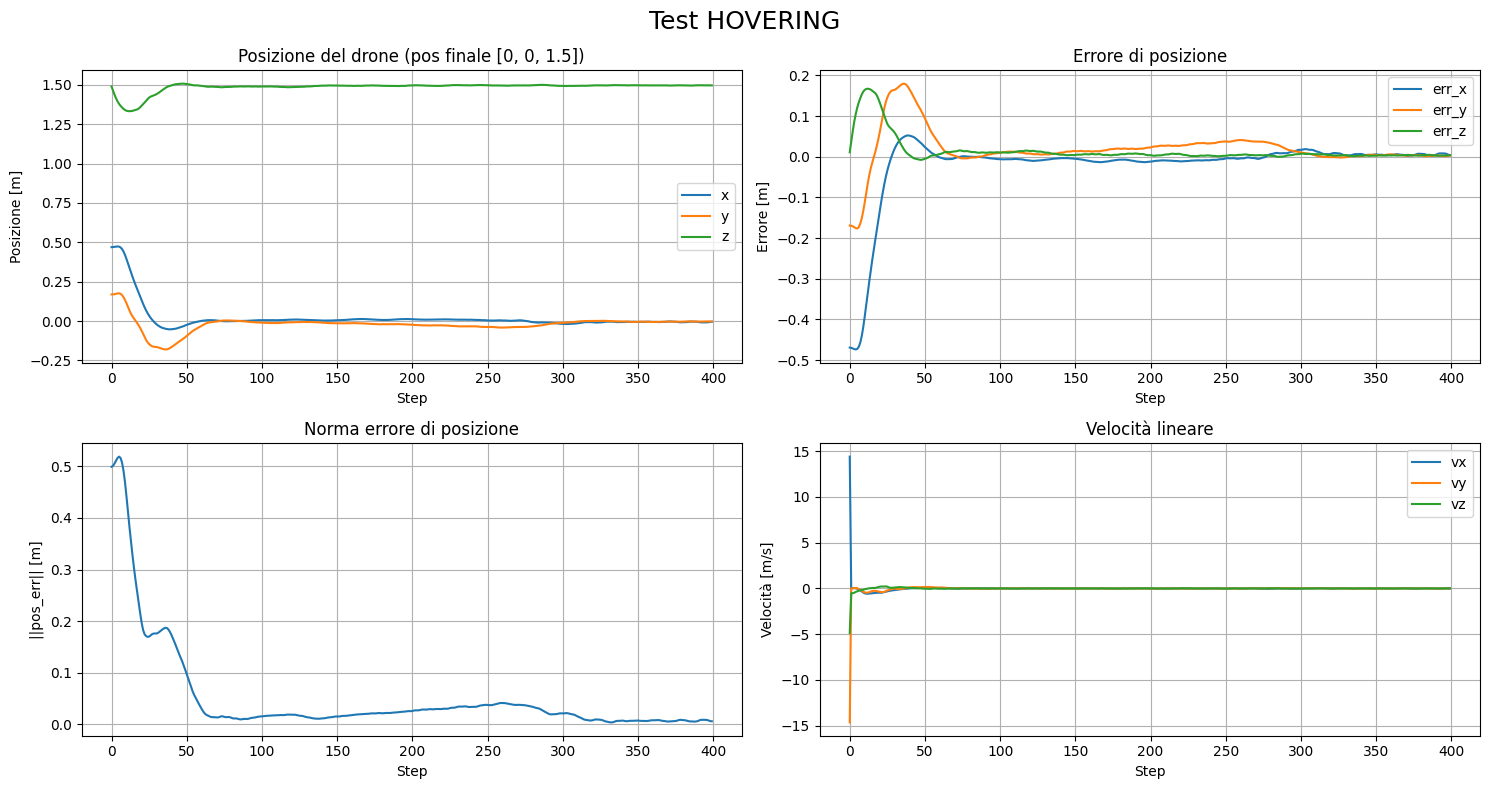

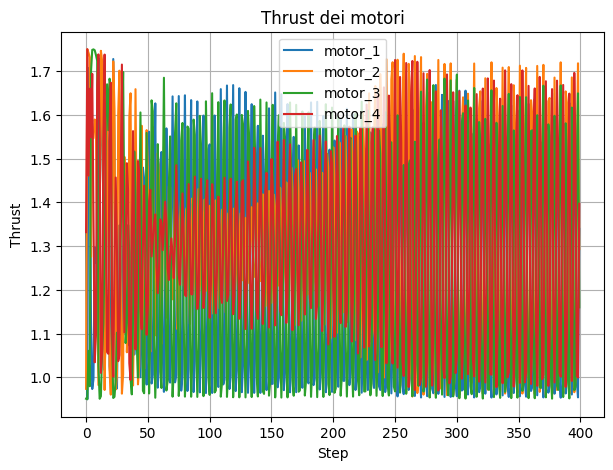

drone handle: 16
drone script handle: 17
Step 0000 | pos=(+0.10, +0.01, +1.67) | ||pos_err||=0.194 m | 
Step 0050 | pos=(-0.02, -0.03, +1.50) | ||pos_err||=0.038 m | 
Step 0100 | pos=(+0.25, -0.01, +1.48) | ||pos_err||=0.118 m | 
Step 0150 | pos=(+0.76, -0.02, +1.50) | ||pos_err||=0.107 m | 
Step 0200 | pos=(+0.99, -0.01, +1.50) | ||pos_err||=0.010 m | 
Step 0250 | pos=(+0.99, +0.00, +1.49) | ||pos_err||=0.010 m | 
Step 0300 | pos=(+1.00, -0.00, +1.50) | ||pos_err||=0.006 m | 
Step 0350 | pos=(+0.99, +0.00, +1.49) | ||pos_err||=0.010 m | 

Episodio terminato allo step 399

--- RIEPILOGO EPISODIO ---
Step totali: 400
Reward totale: 549.60
Posizione finale drone: [ 0.99701023 -0.00352169  1.4962565 ]
Errore finale: [0.00298977 0.00352169 0.00374353]


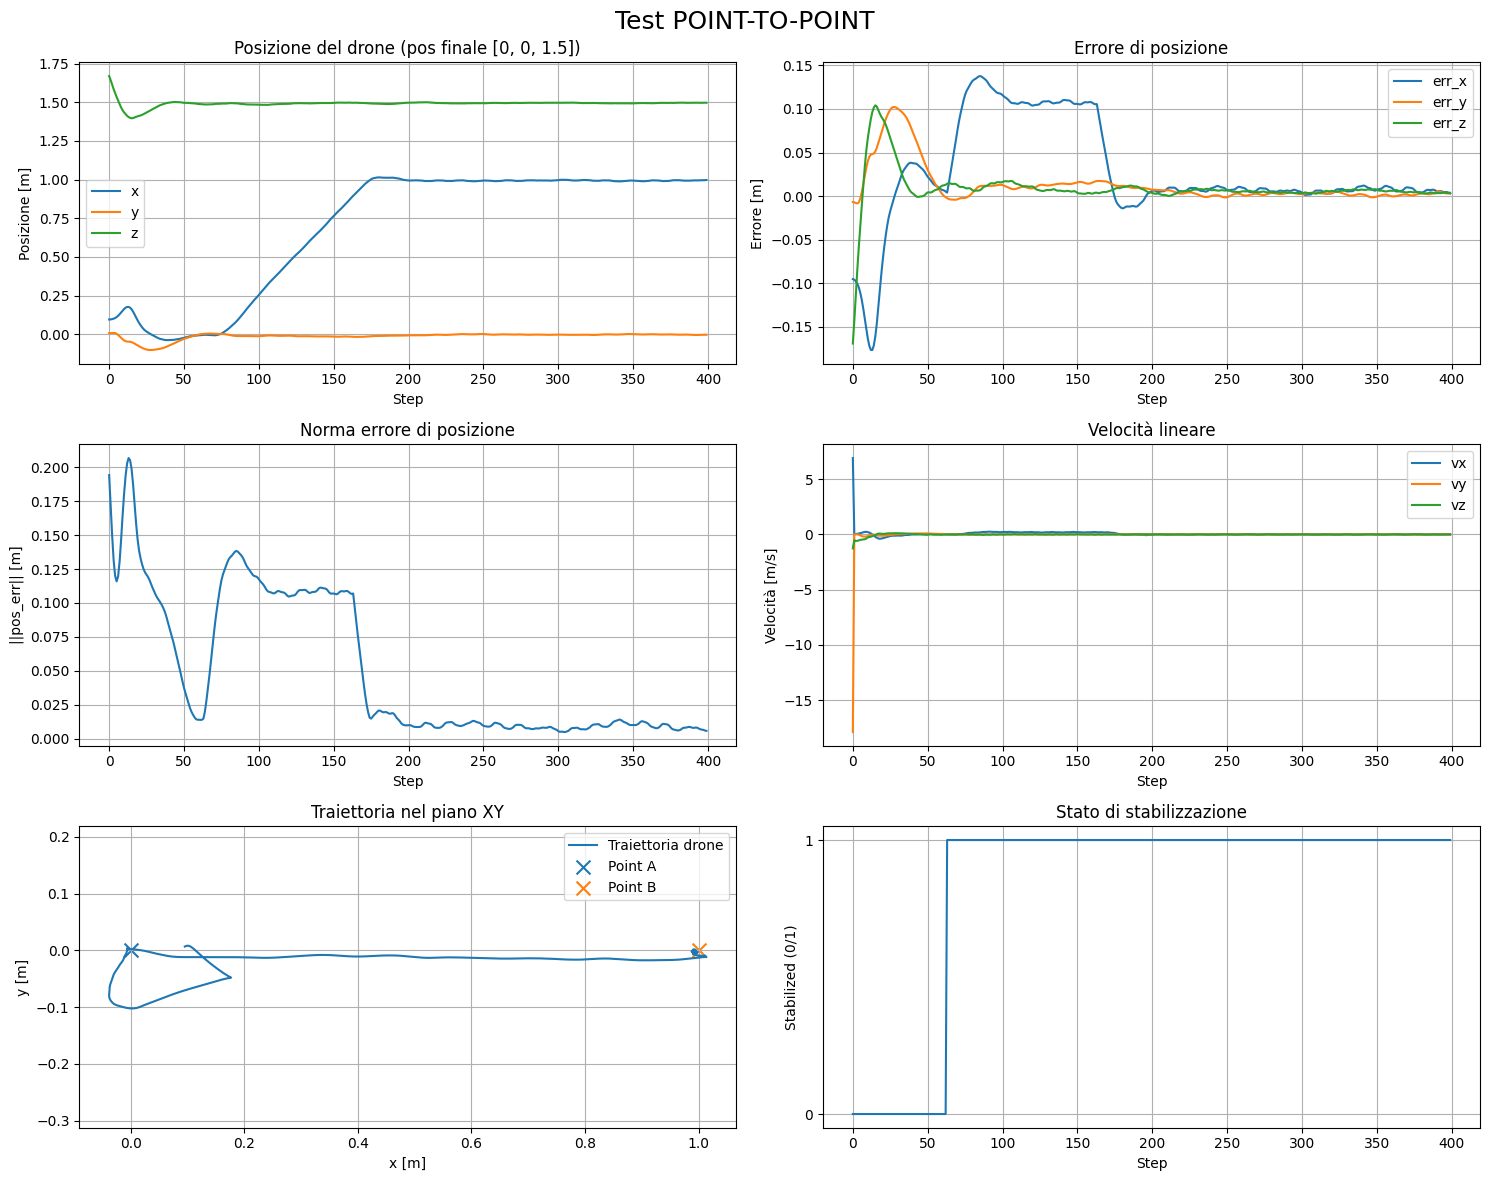

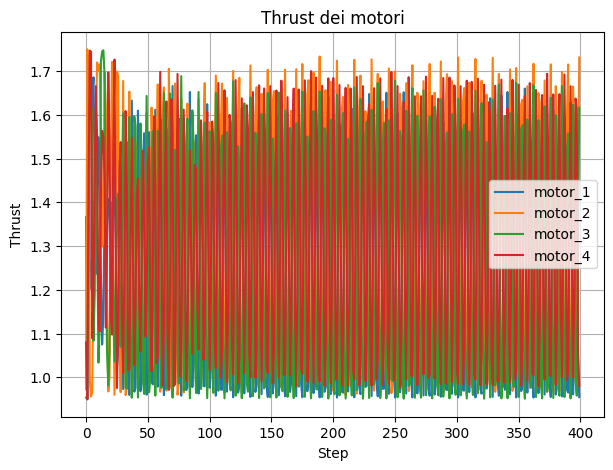

In [53]:
import os
import glob
import time
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_test_episode(ep_data, task = "hovering"):
    steps = np.arange(len(ep_data["step"]))
    drone_pos = np.array(ep_data["drone_pos"])
    target_pos = np.array(ep_data["target_pos"])
    pos_err = np.array(ep_data["pos_err"])
    lin_vel = np.array(ep_data["lin_vel"])
    thrusts = np.array(ep_data["thrusts"])

    pos_err_norm = np.linalg.norm(pos_err, axis=1)

    if task == "point-to-point":
        stabilized = np.array(ep_data["stabilized"], dtype=int)
        pointA = np.array(ep_data["pointA"])
        pointB = np.array(ep_data["pointB"])
        fig, axs = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle("Test POINT-TO-POINT", fontsize=18)
    else:
        fig, axs = plt.subplots(2, 2, figsize=(15, 8))
        fig.suptitle("Test HOVERING", fontsize=18)

    # Posizione drone
    axs[0, 0].plot(steps, drone_pos[:, 0], label="x")
    axs[0, 0].plot(steps, drone_pos[:, 1], label="y")
    axs[0, 0].plot(steps, drone_pos[:, 2], label="z")
    axs[0, 0].set_title("Posizione del drone (pos finale [0, 0, 1.5])")
    axs[0, 0].set_xlabel("Step")
    axs[0, 0].set_ylabel("Posizione [m]")
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Errore di posizione
    axs[0, 1].plot(steps, pos_err[:, 0], label="err_x")
    axs[0, 1].plot(steps, pos_err[:, 1], label="err_y")
    axs[0, 1].plot(steps, pos_err[:, 2], label="err_z")
    axs[0, 1].set_title("Errore di posizione")
    axs[0, 1].set_xlabel("Step")
    axs[0, 1].set_ylabel("Errore [m]")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Norma errore posizione
    axs[1, 0].plot(steps, pos_err_norm)
    axs[1, 0].set_title("Norma errore di posizione")
    axs[1, 0].set_xlabel("Step")
    axs[1, 0].set_ylabel("||pos_err|| [m]")
    axs[1, 0].grid(True)

    # Velocità lineare
    axs[1, 1].plot(steps, lin_vel[:, 0], label="vx")
    axs[1, 1].plot(steps, lin_vel[:, 1], label="vy")
    axs[1, 1].plot(steps, lin_vel[:, 2], label="vz")
    axs[1, 1].set_title("Velocità lineare")
    axs[1, 1].set_xlabel("Step")
    axs[1, 1].set_ylabel("Velocità [m/s]")
    axs[1, 1].legend()
    axs[1, 1].grid(True)


    # Traiettoria XY
    if task == "point-to-point":
        axs[2, 0].plot(drone_pos[:, 0], drone_pos[:, 1], label="Traiettoria drone")
        axs[2, 0].scatter(pointA[0, 0], pointA[0, 1], marker='x', s=100, label="Point A")
        axs[2, 0].scatter(pointB[0, 0], pointB[0, 1], marker='x', s=100, label="Point B")
        axs[2, 0].set_title("Traiettoria nel piano XY")
        axs[2, 0].set_xlabel("x [m]")
        axs[2, 0].set_ylabel("y [m]")
        axs[2, 0].legend()
        axs[2, 0].grid(True)
        axs[2, 0].axis("equal")

        # Stabilized
        axs[2, 1].plot(steps, stabilized)
        axs[2, 1].set_title("Stato di stabilizzazione")
        axs[2, 1].set_xlabel("Step")
        axs[2, 1].set_ylabel("Stabilized (0/1)")
        axs[2, 1].set_yticks([0, 1])
        axs[2, 1].grid(True)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(steps, thrusts[:, 0], label="motor_1")
    plt.plot(steps, thrusts[:, 1], label="motor_2")
    plt.plot(steps, thrusts[:, 2], label="motor_3")
    plt.plot(steps, thrusts[:, 3], label="motor_4")

    plt.title("Thrust dei motori")
    plt.xlabel("Step")
    plt.ylabel("Thrust")
    plt.legend()
    plt.grid(True)
    plt.show()



def start_episode(task ="hovering"):
    if task == "point-to-point":
        env = DroneEnv(host='localhost', port=23000, task="point-to-point")
    else:
        env = DroneEnv(host='localhost', port=23000)
    obs, _ = env.reset()

    max_steps = 1000

    ep_data = {
        "step": [],
        "drone_pos": [],
        "target_pos": [],
        "pos_err": [],
        "lin_vel": [],
        "ang_vel": [],
        "thrusts": [],
        "stabilized": [],
        "pointA": [],
        "pointB": [],
        "reward": [],
    }

    try:
        for i in range(max_steps):
            with torch.no_grad():
                action = agent.policy_model.select_greedy_action(obs)

            obs, reward, terminated, truncated, info = env.step(action)

            ep_data["step"].append(info["step_count"])
            ep_data["drone_pos"].append(info["drone_pos"])
            ep_data["target_pos"].append(info["target_pos"])
            ep_data["pos_err"].append(info["pos_err"])
            ep_data["lin_vel"].append(info["lin_vel"])
            ep_data["ang_vel"].append(info["ang_vel"])
            ep_data["thrusts"].append(info["thrusts"])
            ep_data["reward"].append(reward)

            if task == "point-to-point":
                ep_data["stabilized"].append(info["stabilized"])
                ep_data["pointA"].append(info["pointA"])
                ep_data["pointB"].append(info["pointB"])

            if i % 50 == 0:
                pos_err_norm = np.linalg.norm(info["pos_err"])
                print(
                    f"Step {i:04d} | "
                    f"pos=({info['drone_pos'][0]:+.2f}, {info['drone_pos'][1]:+.2f}, {info['drone_pos'][2]:+.2f}) | "
                    f"||pos_err||={pos_err_norm:.3f} m | "
                )

            if terminated or truncated:
                print(f"\nEpisodio terminato allo step {i}")
                break

        print("\n--- RIEPILOGO EPISODIO ---")
        print(f"Step totali: {len(ep_data['step'])}")
        print(f"Reward totale: {np.sum(ep_data['reward']):.2f}")
        print(f"Posizione finale drone: {ep_data['drone_pos'][-1]}")
        print(f"Errore finale: {ep_data['pos_err'][-1]}")

        # Mostra grafici
        plot_test_episode(ep_data, task)

    except KeyboardInterrupt:
        print("\nTest interrotto manualmente.")
    finally:
        env.close()



# 1. Trova il modello salvato
checkpoint_dir = "./checkpoints"
model_files = glob.glob(os.path.join(checkpoint_dir, "model_1293_ZMQ_Drone_Custom.pth"))

if not model_files:
    print(f"Nessun modello trovato in {checkpoint_dir}")
else:
    latest_model_path = max(
        model_files,
        key=lambda f: int(os.path.basename(f).split('_')[1])
    )
    print(f"Caricamento modello: {latest_model_path}")

    # 2. Carica i pesi
    agent.load_state_dict(torch.load(latest_model_path, map_location=device))
    agent.eval()
    print("Pesi caricati con successo!")
    for i in range(2):
        if i == 0:
            start_episode("hovering")
        else:
            start_episode("point-to-point")


    
